In [81]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F
import argparse

In [82]:
from pyspark.sql.functions import col,countDistinct
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

# RAW DATA (BROZEN LAYER)

In [7]:
# 1. Initialize a local SparkSession if not already active
spark = pyspark.sql.SparkSession.builder \
    .appName("Bronze-Data-Inspection") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# 2. Define the configuration for target historical date partition
target_date_suffix = "2023_01_01"
bronze_root_dir = "datamart/bronze"

# 3. Construct paths to individual source CSV components
lms_csv_path = os.path.join(bronze_root_dir, "lms", f"bronze_loan_daily_{target_date_suffix}.csv")
attr_csv_path = os.path.join(bronze_root_dir, "attributes", f"bronze_attributes_{target_date_suffix}.csv")
fin_csv_path = os.path.join(bronze_root_dir, "financials", f"bronze_financials_{target_date_suffix}.csv")
click_csv_path = os.path.join(bronze_root_dir, "clickstream", f"bronze_clickstream_{target_date_suffix}.csv")

# 4. Load raw CSV data into explicit DataFrames (Enforce headers and auto-schema discovery)
print(f"[INFO] Ingesting raw Bronze CSV data components for partition: {target_date_suffix}")

df_lms_brozen = spark.read.csv(lms_csv_path, header=True, inferSchema=True)
df_attr_brozen = spark.read.csv(attr_csv_path, header=True, inferSchema=True)
df_fin_brozen = spark.read.csv(fin_csv_path, header=True, inferSchema=True)
df_click_brozen = spark.read.csv(click_csv_path, header=True, inferSchema=True)

print("[SUCCESS] All Bronze DataFrames successfully generated and held in cluster memory.\n")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 04:53:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[INFO] Ingesting raw Bronze CSV data components for partition: 2023_01_01


[Stage 7:>                                                          (0 + 2) / 2]

[SUCCESS] All Bronze DataFrames successfully generated and held in cluster memory.



## Attributes

### Occupation

In [9]:
temp = df_attr_brozen.toPandas()

In [10]:
counts = temp['Occupation'].value_counts()
print(counts)

Occupation
_______          880
Lawyer           828
Architect        795
Engineer         793
Accountant       791
Scientist        789
Teacher          782
Media_Manager    780
Mechanic         780
Developer        780
Entrepreneur     776
Journalist       761
Doctor           760
Musician         741
Manager          736
Writer           728
Name: count, dtype: int64


Observation: There are invalid values present: _______
Resolution: replace with NaN

### SSN

In [79]:
counts = temp['SSN'].value_counts()
print(counts)

SSN
#F%$D@*&8      703
340-05-3601      1
514-58-5414      1
085-98-2156      1
212-18-7234      1
              ... 
527-49-4203      1
349-33-5871      1
659-08-8401      1
773-79-4897      1
889-20-8307      1
Name: count, Length: 11798, dtype: int64


Observation: There is invalid data: #F%$D@*&8
Resolution: replace with NaN

### Age

In [82]:
# Step 1: Count values that are NOT standard integers
# Convert to string and use isdigit() to check if they contain only numbers (0-9)
is_digit_mask = temp['Age'].astype(str).str.isdigit()
non_int_count = (~is_digit_mask).sum()

print(f"Count of non-integer/invalid values: {non_int_count}")

# Step 2: Safely convert the column to numeric
# 'errors="coerce"' will turn any unparseable string (like 'Unknown' or '-') into NaN
clean_age = pd.to_numeric(temp['Age'], errors='coerce')

# Step 3: Find the Minimum and Maximum values
# Pandas automatically ignores NaN values when calculating min() and max()
age_min = clean_age.min()
age_max = clean_age.max()

print(f"Minimum Age: {age_min}")
print(f"Maximum Age: {age_max}")

Count of non-integer/invalid values: 741
Minimum Age: -500.0
Maximum Age: 8678.0


In [81]:
# 1. Convert 'Age' to numeric first, turning invalid strings into NaN
clean_age = pd.to_numeric(temp['Age'], errors='coerce')

# 2. Filter the data to keep only ages within the 10-100 threshold
# The .between() function is inclusive by default (includes both 10 and 100)
valid_ages = clean_age[clean_age.between(10, 100)]

# Alternative using boolean indexing if you don't want to use .between():
# valid_ages = clean_age[(clean_age >= 10) & (clean_age <= 100)]

# 3. Find the minimum and maximum values of the filtered data
min_age = valid_ages.min()
max_age = valid_ages.max()

print(f"Minimum Age (10-100 threshold): {min_age}")
print(f"Maximum Age (10-100 threshold): {max_age}")

Minimum Age (18-100 threshold): 14.0
Maximum Age (18-100 threshold): 56.0


Observation: There are many invalid values in 2 cases:
- Contains special characters
- Age is negative or too large

Resolution: for numbers containing special characters, remove the special characters to convert the data into numeric form, then all numeric values exceeding the threshold are replaced with MODE(AGE)

### Customer_ID

In [83]:
# Count the total number of duplicated Customer_IDs
# keep='first' (default) means it marks the 2nd, 3rd, etc., occurrences as True
duplicate_count = temp['Customer_ID'].duplicated().sum()

print(f"Total duplicated Customer IDs: {duplicate_count}")

Total duplicated Customer IDs: 0


Nothing needs to be modified

### Name

Nothing needs to be modified

## LMS

In [85]:
temp = df_lms_brozen.toPandas()

In [87]:
temp['Customer_ID'].duplicated().sum()

np.int64(0)

Nothing to handle — the data table has already been processed very well

## Financials

In [106]:
temp = df_fin_brozen.toPandas()

In [107]:
temp['Customer_ID'].duplicated().sum()

np.int64(0)

In [108]:
counts = temp['Credit_Mix'].value_counts()
print(counts)

Credit_Mix
Standard    4497
Good        3032
_           2611
Bad         2360
Name: count, dtype: int64


In [109]:
counts = temp['Payment_of_Min_Amount'].value_counts()
print(counts)

Payment_of_Min_Amount
Yes    6571
No     4491
NM     1438
Name: count, dtype: int64


In [110]:
counts = temp['Payment_Behaviour'].value_counts()
print(counts)

Payment_Behaviour
Low_spent_Small_value_payments      3202
High_spent_Medium_value_payments    2242
Low_spent_Medium_value_payments     1686
High_spent_Large_value_payments     1683
High_spent_Small_value_payments     1389
Low_spent_Large_value_payments      1300
!@9#%8                               998
Name: count, dtype: int64


Apply the same approach to identify the processing steps needed:
- Annual_Income, Monthly_Inhand_Salary, Changed_Credit_Limit, Outstanding_Debt, Credit_Utilization_Ratio, Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance: remove special characters and convert to integer values
- Payment_Behaviour: replace !@9#%8 values with NaN
- Credit_Mix: replace _ values with NaN
- Type_of_Loan: parse the string and store as an array for easier processing in the gold layer
- Number_Bank_Account, Num_Credit_Card: values > 15 or < 0 are replaced with Mode
- Interest_Rate: values > 40 or < 0 are replaced with Mode
- Num_of_Loan: values < 0 or > 15 are replaced with the length of Type_of_Loan
- Delay_from_due_date: negative numbers converted to absolute value
- Num_Credit_Inquiries: values < 0 or > 25 are replaced with Mode

## Clickstream

In [95]:
temp = df_click_brozen.toPandas()

In [96]:
temp

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215371,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
215372,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
215373,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
215374,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


In [98]:
# Assuming 'temp' is already created via: temp = df_click_brozen.toPandas()

# 1. Generate the list of target feature names ['fe_1', 'fe_2', ..., 'fe_20']
features = [f'fe_{i}' for i in range(1, 21)]

# 2. Initialize an empty list to store the statistical results
stats_list = []

for col in features:
    # Check if the column actually exists in the DataFrame to prevent errors
    if col in temp.columns:
        # Convert column to numeric just in case there are hidden strings (coercing errors to NaN)
        numeric_col = pd.to_numeric(temp[col], errors='coerce')
        
        # 3. Count the number of negative values
        negative_count = (numeric_col < 0).sum()
        
        # 4. Filter out negative values by keeping only values >= 0 (negatives become NaN)
        # Pandas automatically ignores NaN values when calculating mean, median, and mode
        valid_data = numeric_col.where(numeric_col >= 0)
        
        # 5. Calculate statistics on the valid data
        mean_val = valid_data.mean()
        median_val = valid_data.median()
        
        # Mode can return multiple values, so we extract the first one safely
        mode_series = valid_data.mode()
        mode_val = mode_series.iloc[0] if not mode_series.empty else np.nan
        
        # 6. Append the results as a dictionary
        stats_list.append({
            'Feature': col,
            'Negative_Count': negative_count,
            'Mean': mean_val,
            'Median': median_val,
            'Mode': mode_val
        })

# 7. Convert the collected list of dictionaries into a clean DataFrame for viewing
df_stats = pd.DataFrame(stats_list)

# Display the final statistics table
print(df_stats)

   Feature  Negative_Count        Mean  Median   Mode
0     fe_1           33159  129.346592   121.0  122.0
1     fe_2           32170  130.414915   122.0  108.0
2     fe_3           32079  131.779865   123.0  111.0
3     fe_4           31150  132.349288   124.0   82.0
4     fe_5           30734  133.534402   125.0  103.0
5     fe_6           32353  130.763314   122.0  100.0
6     fe_7           30479  133.258576   125.0  117.0
7     fe_8           28891  135.741609   128.0  110.0
8     fe_9           27224  138.244122   130.0  103.0
9    fe_10           25995  140.814385   133.0  124.0
10   fe_11           34235  128.506611   120.0  115.0
11   fe_12           34194  128.804136   120.0  114.0
12   fe_13           34137  129.461639   121.0  103.0
13   fe_14           34541  129.324368   120.0   99.0
14   fe_15           34778  129.156126   120.0   97.0
15   fe_16           34318  128.996161   120.0  103.0
16   fe_17           34460  129.476204   121.0   74.0
17   fe_18           34733  

In [ ]:
# 1. Define the target features to analyze
features = [f'fe_{i}' for i in range(1, 21)]

# 2. Initialize a list to store the frequency results
negative_freq_list = []
total_rows = len(temp)

for col in features:
    if col in temp.columns:
        # Convert column to numeric, ignoring non-numeric junk
        numeric_col = pd.to_numeric(temp[col], errors='coerce')
        
        # 3. Filter only the negative values from the column
        negatives = numeric_col[numeric_col < 0]
        
        # 4. If negative values exist, calculate their frequencies
        if not negatives.empty:
            # Get the exact count of each unique negative number
            value_counts = negatives.value_counts()
            
            for val, count in value_counts.items():
                # Calculate what percentage this specific value represents in the whole dataset
                percentage_overall = (count / total_rows) * 100
                
                # Append the metrics to our tracking list
                negative_freq_list.append({
                    'Feature': col,
                    'Negative_Value': val,
                    'Count': count,
                    'Percentage_Overall (%)': round(percentage_overall, 2)
                })

# 5. Convert the results into a DataFrame for easy viewing
df_negative_freq = pd.DataFrame(negative_freq_list)

# 6. Sort the results to show the most frequent negative values first
if not df_negative_freq.empty:
    df_negative_freq = df_negative_freq.sort_values(
        by=['Feature', 'Count'], 
        ascending=[True, False]
    )
    # Display the final summary table
    print(df_negative_freq.to_string(index=False))
else:
    print("No negative values found in the specified columns.")

After analyzing the frequency of negative values, we noticed that some negative values appear very frequently. Therefore, in this case the negative numbers may follow a convention or carry some meaning, so we do not remove them.

# Cleaning DATA (SILVER LAYER)

In [76]:
# 1. Initialize a local SparkSession for data inspection
spark = pyspark.sql.SparkSession.builder \
    .appName("Silver-Data-Inspection") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# 2. Define target file paths (Adjust the date suffix to match your generated files)
target_date_suffix = "2023_01_01"
silver_root_dir = "datamart/silver"

lms_parquet_path = os.path.join(silver_root_dir, "loan_daily", f"silver_loan_daily_{target_date_suffix}.parquet")
attr_parquet_path = os.path.join(silver_root_dir, "attributes", f"silver_attributes_{target_date_suffix}.parquet")
fin_parquet_path = os.path.join(silver_root_dir, "financials", f"silver_financials_{target_date_suffix}.parquet")
click_parquet_path = os.path.join(silver_root_dir, "clickstream", f"silver_clickstream_{target_date_suffix}.parquet")

print("[INFO] Target paths initialized for inspection.")

[INFO] Target paths initialized for inspection.


In [78]:
# Read and inspect LMS Silver Parquet asset
df_lms_silver = spark.read.parquet(lms_parquet_path)

print(f"LMS Silver Record Count: {df_lms_silver.count()}")
df_lms_silver.printSchema()

# Convert a small subset to Pandas for an elegant grid visual display in Notebook
df_lms_silver.limit(50).toPandas()

LMS Silver Record Count: 530
root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: float (nullable = true)
 |-- due_amt: float (nullable = true)
 |-- paid_amt: float (nullable = true)
 |-- overdue_amt: float (nullable = true)
 |-- balance: float (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- mob: integer (nullable = true)
 |-- installments_missed: integer (nullable = true)
 |-- first_missed_date: date (nullable = true)
 |-- dpd: integer (nullable = true)



,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x1037_2023_01_01,CUS_0x1037,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
1,CUS_0x1069_2023_01_01,CUS_0x1069,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
2,CUS_0x114a_2023_01_01,CUS_0x114a,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
3,CUS_0x1184_2023_01_01,CUS_0x1184,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
4,CUS_0x1297_2023_01_01,CUS_0x1297,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
5,CUS_0x12fb_2023_01_01,CUS_0x12fb,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
6,CUS_0x1325_2023_01_01,CUS_0x1325,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
7,CUS_0x1341_2023_01_01,CUS_0x1341,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
8,CUS_0x1375_2023_01_01,CUS_0x1375,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
9,CUS_0x13a8_2023_01_01,CUS_0x13a8,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0


In [79]:
# Read and inspect ATTR Silver Parquet asset
df_attr_silver = spark.read.parquet(attr_parquet_path)

print(f"Attributes Silver Record Count: {df_lms_silver.count()}")
df_attr_silver.printSchema()

# Convert a small subset to Pandas for an elegant grid visual display in Notebook
df_attr_silver.limit(50).toPandas()

Attributes Silver Record Count: 530
root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,None,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01
5,CUS_0x1015,Holtono,27,810-97-7024,Journalist,2023-08-01
6,CUS_0x1018,Felsenthalq,39,731-19-8119,Accountant,2023-11-01
7,CUS_0x1026,Josephv,52,500-62-9044,Manager,2023-10-01
8,CUS_0x102d,Neil Chatterjeex,31,692-71-7552,Entrepreneur,2024-01-01
9,CUS_0x102e,Rhysn,26,None,Scientist,2024-04-01


In [114]:
# Read and inspect Financials Silver Parquet asset
df_fin_silver = spark.read.parquet(fin_parquet_path)

print(f"Financials Silver Record Count: {df_lms_silver.count()}")
df_fin_silver.printSchema()

# Convert a small subset to Pandas for an elegant grid visual display in Notebook
df_fin_silver.limit(50).toPandas()

Financials Silver Record Count: 530
root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: float (nullable = true)
 |-- Monthly_Inhand_Salary: float (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: double (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: floa

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1011,5.891847e+04,5208.872559,3,3,17.0,3,"[Student Loan, Credit-Builder Loan, and Debt C...",27,13,...,Standard,473.140015,27.829960,15 Years and 10 Months,Yes,123.434937,383.350830,Low_spent_Medium_value_payments,294.101471,2023-11-01
1,CUS_0x1013,9.862098e+04,7962.415039,3,3,6.0,3,"[Student Loan, Debt Consolidation Loan, and Pe...",12,9,...,Good,1233.510010,26.524864,17 Years and 10 Months,No,228.018082,332.333710,High_spent_Medium_value_payments,485.889709,2023-12-01
2,CUS_0x1015,4.695102e+04,3725.584961,7,4,16.0,0,None,8,9,...,Standard,340.220001,38.682232,21 Years and 5 Months,None,0.000000,437.433990,Low_spent_Small_value_payments,225.124512,2023-08-01
3,CUS_0x1026,1.706143e+05,14463.856445,2,6,9.0,2,"[Payday Loan, and Auto Loan]",0,5,...,Good,849.690002,31.757521,20 Years and 8 Months,No,208.907486,184.277878,High_spent_Medium_value_payments,1303.200317,2023-10-01
4,CUS_0x102d,8.906452e+04,7256.043457,5,3,1.0,1,[Mortgage Loan],6,5,...,None,648.359985,30.574299,30 Years and 3 Months,No,37.572750,296.094116,High_spent_Medium_value_payments,641.937439,2024-01-01
5,CUS_0x1037,1.598908e+04,1086.423706,5,4,2.0,4,"[Credit-Builder Loan, Auto Loan, Auto Loan, an...",13,15,...,Good,665.820007,40.697701,19 Years and 9 Months,No,33.797020,80.465240,Low_spent_Small_value_payments,284.380127,2023-01-01
6,CUS_0x1038,1.294732e+05,10959.429688,3,4,10.0,3,"[Payday Loan, Payday Loan, and Home Equity Loan]",28,13,...,Standard,568.210022,34.089317,20 Years and 0 Months,Yes,255.327911,1088.271484,Low_spent_Medium_value_payments,32.343647,2024-10-01
7,CUS_0x1041,8.978110e+03,894.175842,8,8,30.0,9,"[Payday Loan, Mortgage Loan, Payday Loan, Mort...",50,17,...,Bad,4913.149902,37.746567,10 Years and 5 Months,Yes,57.679657,43.565857,High_spent_Small_value_payments,248.172073,2023-11-01
8,CUS_0x1044,3.344159e+04,2748.799072,2,4,1.0,0,None,1,4,...,None,154.960007,35.984108,31 Years and 11 Months,No,0.000000,229.532257,Low_spent_Small_value_payments,335.347656,2023-06-01
9,CUS_0x104a,1.498139e+04,1461.449219,2,7,5.0,4,"[Mortgage Loan, Auto Loan, Not Specified, and ...",5,6,...,Good,1122.459961,39.641644,32 Years and 3 Months,No,38.115967,164.889175,Low_spent_Small_value_payments,233.139771,2023-12-01


In [104]:
# Read and inspect Clickstream Silver Parquet asset
df_click_silver = spark.read.parquet(click_parquet_path)

print(f"Financials Clickstream Record Count: {df_lms_silver.count()}")
df_click_silver.printSchema()

# Convert a small subset to Pandas for an elegant grid visual display in Notebook
df_click_silver.limit(50).toPandas()

Financials Clickstream Record Count: 530
root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01
5,-133,114,138,84,53,-60,60,128,349,102,...,200,168,32,-85,91,185,134,-28,CUS_0x12fb,2023-01-01
6,67,155,24,-16,205,80,355,140,201,87,...,71,72,78,238,96,147,51,155,CUS_0x1325,2023-01-01
7,-64,93,36,-1,3,183,-129,122,164,138,...,143,90,354,280,121,159,-81,-27,CUS_0x1341,2023-01-01
8,167,37,169,155,4,151,99,192,-64,-207,...,167,43,216,287,115,183,66,55,CUS_0x1375,2023-01-01
9,356,-23,-4,-46,80,167,258,174,104,65,...,145,211,140,113,31,136,36,125,CUS_0x13a8,2023-01-01


# Gold Layer

In [149]:
def load_silver_data(start_date_str: str = "2023-01-01", end_date_str: str = "2025-11-01"):
    """
    Scans, reads, and filters all 4 Silver layer tables within a specified date range.
    Uses wildcard patterns to load multiple files in parallel without any loops.
    
    Parameters:
    -----------
    start_date_str : str
        The lower bound of the snapshot date range (format: 'YYYY-MM-DD').
    end_date_str : str
        The upper bound of the snapshot date range (format: 'YYYY-MM-DD').
        
    Returns:
    --------
    tuple of PySpark DataFrames
        (df_lms, df_click, df_attr, df_fin) ready for further data pipeline stages.
    """
    # 1. Define the root directory for Silver layer data
    silver_root_dir = "datamart/silver"

    # 2. Formulate paths using wildcard (*) to scan all underlying Parquet files efficiently
    lms_pattern = os.path.join(silver_root_dir, "loan_daily", "*.parquet")
    click_pattern = os.path.join(silver_root_dir, "clickstream", "*.parquet")
    attr_pattern = os.path.join(silver_root_dir, "attributes", "*.parquet")
    fin_pattern = os.path.join(silver_root_dir, "financials", "*.parquet")

    # 3. Read the complete directory contents into parallelized DataFrames
    print(f"[INFO] Scanning Silver layer paths dynamically...")
    df_lms_raw = spark.read.parquet(lms_pattern)
    df_click_raw = spark.read.parquet(click_pattern)
    df_attr_raw = spark.read.parquet(attr_pattern)
    df_fin_raw = spark.read.parquet(fin_pattern)

    # 4. Filter the time-series dynamic dataframes based on the requested date window
    print(f"[INFO] Applying chronological filter: {start_date_str} to {end_date_str}")
    df_lms = df_lms_raw.filter((F.col("snapshot_date") >= start_date_str) & (F.col("snapshot_date") <= end_date_str))
    df_click = df_click_raw.filter((F.col("snapshot_date") >= start_date_str) & (F.col("snapshot_date") <= end_date_str))
    df_attr = df_attr_raw.filter((F.col("snapshot_date") >= start_date_str) & (F.col("snapshot_date") <= end_date_str))
    df_fin = df_fin_raw.filter((F.col("snapshot_date") >= start_date_str) & (F.col("snapshot_date") <= end_date_str))


    print(f"[SUCCESS] All 4 DataFrames loaded and filtered successfully.")
    return df_lms, df_click, df_attr, df_fin

In [118]:
# Initialize SparkSession with driver host config
spark = pyspark.sql.SparkSession.builder \
    .appName("Silver-Data-Inspection") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [119]:
start_date_str = "2023-01-01"
end_date_str = "2025-11-01"

In [120]:
df_lms, df_click, df_attr, df_fin = load_silver_data(end_date_str = end_date_str)

[INFO] Scanning Silver layer paths dynamically...
[INFO] Applying chronological filter: 2023-01-01 to 2025-11-01
[SUCCESS] All 4 DataFrames loaded and filtered successfully.


In [121]:
df_lms.count()

137500

In [122]:
df_attr.count()

12500

The labeling step uses the overdue_amt method instead of dbd

In [123]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# 1. Define the window spec: partition by customer and order by snapshot date descending
window_spec = Window.partitionBy("Customer_ID").orderBy(F.col("snapshot_date").desc())

# 2. Assign a row number to each record; the latest record will have row_num = 1
df_ranked = df_lms.withColumn("row_num", F.row_number().over(window_spec))

# 3. Filter for row_num == 1 to get the last record per customer, then create 'isDefault'
df_default_labels = df_ranked.filter(F.col("row_num") == 1) \
    .select("Customer_ID", "overdue_amt") \
    .withColumn(
        "isDefault",
        F.when(F.col("overdue_amt") > 0, 1).otherwise(0)
    )

# 4. Verify and inspect the newly created label DataFrame based on the last snapshot
print(f"[SUCCESS] Label DataFrame created using latest snapshot. Total rows: {df_default_labels.count()}")
df_default_labels.printSchema()
df_default_labels.show(10, truncate=False)

[SUCCESS] Label DataFrame created using latest snapshot. Total rows: 12500
root
 |-- Customer_ID: string (nullable = true)
 |-- overdue_amt: float (nullable = true)
 |-- isDefault: integer (nullable = false)

+-----------+-----------+---------+
|Customer_ID|overdue_amt|isDefault|
+-----------+-----------+---------+
|CUS_0x1000 |6000.0     |1        |
|CUS_0x1009 |0.0        |0        |
|CUS_0x100b |0.0        |0        |
|CUS_0x1011 |0.0        |0        |
|CUS_0x1013 |0.0        |0        |
|CUS_0x1015 |0.0        |0        |
|CUS_0x1018 |7000.0     |1        |
|CUS_0x1026 |0.0        |0        |
|CUS_0x102d |0.0        |0        |
|CUS_0x102e |8000.0     |1        |
+-----------+-----------+---------+
only showing top 10 rows



## Bivariate Analysis

### Num_of_Loan


In [124]:
from pyspark.sql.functions import col, count, sum, avg, round

# 1. Select only necessary columns to optimize memory and join operations
df_fin_subset = df_fin.select("Customer_ID", "Num_of_Loan")
df_label_subset = df_default_labels.select("Customer_ID", "isDefault")

# 2. Join the two dataframes using inner join on Customer_ID
df_joined = df_fin_subset.join(df_label_subset, on="Customer_ID", how="inner")

# 3. Clean data: Filter out nulls and illogical negative values in Num_of_Loan
# Assuming Num_of_Loan cannot be negative
df_cleaned = df_joined.filter(col("Num_of_Loan").isNotNull() & (col("Num_of_Loan") >= 0))

# 4. Aggregate data to calculate Default Rate for each Num_of_Loan category
df_loan_bivariate = df_cleaned.groupBy("Num_of_Loan") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy("Num_of_Loan")

# Show the aggregated result in Spark
df_loan_bivariate.show()

+-----------+---------------+--------------+--------------------+
|Num_of_Loan|Total_Customers|Total_Defaults|Default_Rate_Percent|
+-----------+---------------+--------------+--------------------+
|          0|           1426|           196|               13.74|
|          1|           1391|           193|               13.87|
|          2|           1964|           463|               23.57|
|          3|           1969|           444|               22.55|
|          4|           1932|           435|               22.52|
|          5|            941|           449|               47.72|
|          6|           1018|           495|               48.62|
|          7|            960|           473|               49.27|
|          8|            417|           221|                53.0|
|          9|            482|           233|               48.34|
+-----------+---------------+--------------+--------------------+



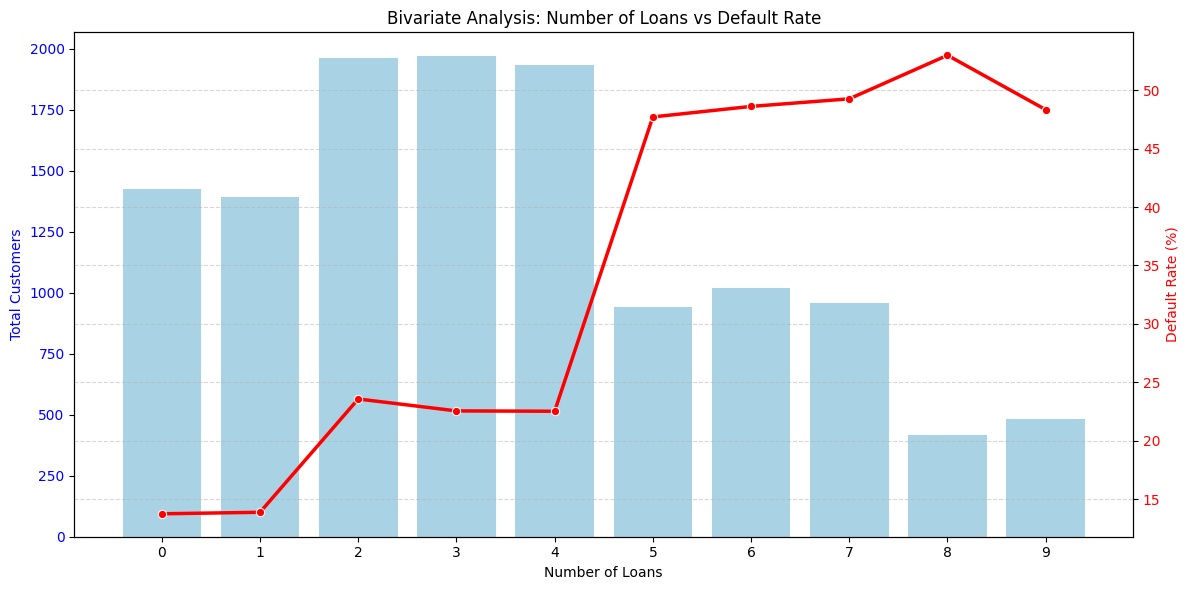

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert Spark DataFrame to Pandas DataFrame for visualization
# Note: Only do this after aggregation when the dataset size is small
pdf_loan_bivariate = df_loan_bivariate.toPandas()

# 2. Set up the matplotlib figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Plot Total_Customers as a Bar Chart on the primary y-axis
sns.barplot(
    data=pdf_loan_bivariate, 
    x='Num_of_Loan', 
    y='Total_Customers', 
    color='skyblue', 
    alpha=0.8, 
    ax=ax1
)
ax1.set_ylabel('Total Customers', color='blue')
ax1.set_xlabel('Number of Loans')
ax1.tick_params(axis='y', labelcolor='blue')

# 4. Create a secondary y-axis to plot the Default Rate
ax2 = ax1.twinx()

# 5. Plot Default_Rate_Percent as a Line Chart on the secondary y-axis
sns.lineplot(
    data=pdf_loan_bivariate, 
    x='Num_of_Loan', 
    y='Default_Rate_Percent', 
    color='red', 
    marker='o', 
    linewidth=2.5, 
    ax=ax2
)
ax2.set_ylabel('Default Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 6. Add title and display the plot
plt.title('Bivariate Analysis: Number of Loans vs Default Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

As the number of loans increases, the default rate also increases. However, we observe that Number_of_Loans = 0 still has a default probability and includes as many as 49,910 customers (which cannot be dropped) — likely because those loans have already been sold off to debt collection companies.

### Monthly_Inhand_Salary

In [99]:
from pyspark.ml.feature import QuantileDiscretizer
from pyspark.sql.functions import col, count, sum, avg, round

# 1. Create a FULL joined dataframe for all subsequent EDA tasks
# We join the entire df_fin with just the isDefault label from df_default_labels
df_joined_full = df_fin.join(
    df_default_labels.select("Customer_ID", "isDefault"), 
    on="Customer_ID", 
    how="inner"
)

# 2. Select columns for Salary analysis and filter out nulls or invalid negative salaries
df_salary = df_joined_full.select("Customer_ID", "Monthly_Inhand_Salary", "isDefault") \
    .filter(col("Monthly_Inhand_Salary").isNotNull() & (col("Monthly_Inhand_Salary") > 0))

# 3. Use QuantileDiscretizer to divide salary into 5 buckets (Quintiles)
# Bucket 0 will be the lowest income group, Bucket 4 will be the highest
discretizer = QuantileDiscretizer(
    numBuckets=5, 
    inputCol="Monthly_Inhand_Salary", 
    outputCol="Salary_Bucket"
)

# Fit and transform the data
df_bucketed = discretizer.fit(df_salary).transform(df_salary)

# 4. Aggregate to calculate Default Rate per Salary Bucket
df_salary_bivariate = df_bucketed.groupBy("Salary_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Monthly_Inhand_Salary"), 2).alias("Avg_Salary_in_Bucket")
    ) \
    .orderBy("Salary_Bucket")

# Show the aggregated result
df_salary_bivariate.show()

+-------------+---------------+--------------+--------------------+--------------------+
|Salary_Bucket|Total_Customers|Total_Defaults|Default_Rate_Percent|Avg_Salary_in_Bucket|
+-------------+---------------+--------------+--------------------+--------------------+
|          0.0|           2490|           991|                39.8|             1053.94|
|          1.0|           2499|           720|               28.81|             1909.56|
|          2.0|           2498|           690|               27.62|             3151.17|
|          3.0|           2500|           797|               31.88|             5332.15|
|          4.0|           2513|           404|               16.08|             9454.48|
+-------------+---------------+--------------+--------------------+--------------------+



### Num_Bank_Accounts

In [100]:
from pyspark.sql.functions import col, count, sum, avg, round

# 1. Select only necessary columns to optimize memory and join operations
df_fin_subset = df_fin.select("Customer_ID", "Num_Bank_Accounts")
df_label_subset = df_default_labels.select("Customer_ID", "isDefault")

# 2. Join the two dataframes using inner join on Customer_ID
df_joined = df_fin_subset.join(df_label_subset, on="Customer_ID", how="inner")

# 3. Clean data: Filter out nulls and illogical negative values in Num_Bank_Accounts
# Assuming Num_Bank_Accounts cannot be negative
df_cleaned = df_joined.filter(col("Num_Bank_Accounts").isNotNull() & (col("Num_Bank_Accounts") >= 0))

# 4. Aggregate data to calculate Default Rate for each Num_Bank_Accounts category
df_bank_account_bivariate = df_cleaned.groupBy("Num_Bank_Accounts") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy("Num_Bank_Accounts")

# Show the aggregated result in Spark
df_bank_account_bivariate.show()

+-----------------+---------------+--------------+--------------------+
|Num_Bank_Accounts|Total_Customers|Total_Defaults|Default_Rate_Percent|
+-----------------+---------------+--------------+--------------------+
|                0|            542|            90|               16.61|
|                1|            566|           100|               17.67|
|                2|            543|            86|               15.84|
|                3|           1485|           241|               16.23|
|                4|           1560|           295|               18.91|
|                5|           1550|           276|               17.81|
|                6|           1656|           579|               34.96|
|                7|           1641|           592|               36.08|
|                8|           1616|           572|                35.4|
|                9|            687|           402|               58.52|
|               10|            651|           367|              

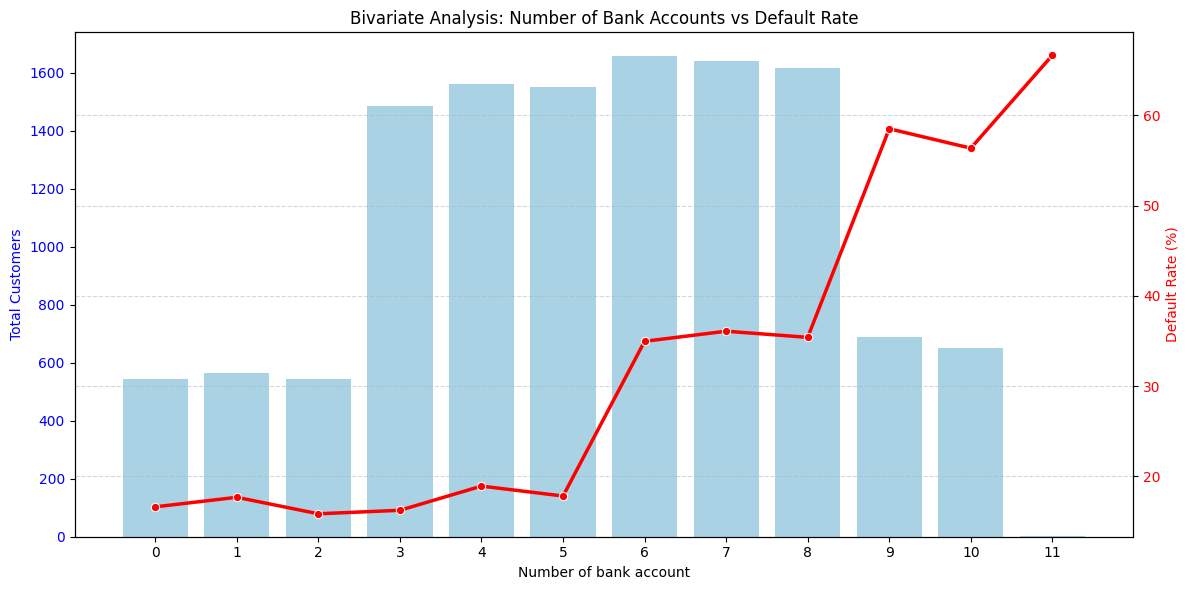

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert Spark DataFrame to Pandas DataFrame for visualization
# Note: Only do this after aggregation when the dataset size is small
pdf_bank_account_bivariate = df_bank_account_bivariate.toPandas()

# 2. Set up the matplotlib figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Plot Total_Customers as a Bar Chart on the primary y-axis
sns.barplot(
    data=pdf_bank_account_bivariate, 
    x='Num_Bank_Accounts', 
    y='Total_Customers', 
    color='skyblue', 
    alpha=0.8, 
    ax=ax1
)
ax1.set_ylabel('Total Customers', color='blue')
ax1.set_xlabel('Number of bank account')
ax1.tick_params(axis='y', labelcolor='blue')

# 4. Create a secondary y-axis to plot the Default Rate
ax2 = ax1.twinx()

# 5. Plot Default_Rate_Percent as a Line Chart on the secondary y-axis
sns.lineplot(
    data=pdf_bank_account_bivariate, 
    x='Num_Bank_Accounts', 
    y='Default_Rate_Percent', 
    color='red', 
    marker='o', 
    linewidth=2.5, 
    ax=ax2
)
ax2.set_ylabel('Default Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 6. Add title and display the plot
plt.title('Bivariate Analysis: Number of Bank Accounts vs Default Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Shows a similar trend to Num_of_Loans

### Num_Credit_Card

In [102]:
from pyspark.sql.functions import col, count, sum, avg, round

# 1. Select only necessary columns to optimize memory and join operations
df_fin_subset = df_fin.select("Customer_ID", "Num_Credit_Card")
df_label_subset = df_default_labels.select("Customer_ID", "isDefault")

# 2. Join the two dataframes using inner join on Customer_ID
df_joined = df_fin_subset.join(df_label_subset, on="Customer_ID", how="inner")

# 3. Clean data: Filter out nulls and illogical negative values in Num_Credit_Card
# Assuming Num_Bank_Accounts cannot be negative
df_cleaned = df_joined.filter(col("Num_Credit_Card").isNotNull() & (col("Num_Credit_Card") >= 0))

# 4. Aggregate data to calculate Default Rate for each Num_Credit_Card category
df_num_credit_bivariate = df_cleaned.groupBy("Num_Credit_Card") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy("Num_Credit_Card")

# Show the aggregated result in Spark
df_num_credit_bivariate.show()

+---------------+---------------+--------------+--------------------+
|Num_Credit_Card|Total_Customers|Total_Defaults|Default_Rate_Percent|
+---------------+---------------+--------------+--------------------+
|              0|              4|             0|                 0.0|
|              1|            259|             1|                0.39|
|              2|            277|             5|                1.81|
|              3|           1647|           274|               16.64|
|              4|           1778|           289|               16.25|
|              5|           2476|           687|               27.75|
|              6|           2110|           624|               29.57|
|              7|           2135|           678|               31.76|
|              8|            611|           343|               56.14|
|              9|            586|           341|               58.19|
|             10|            609|           357|               58.62|
|             11|   

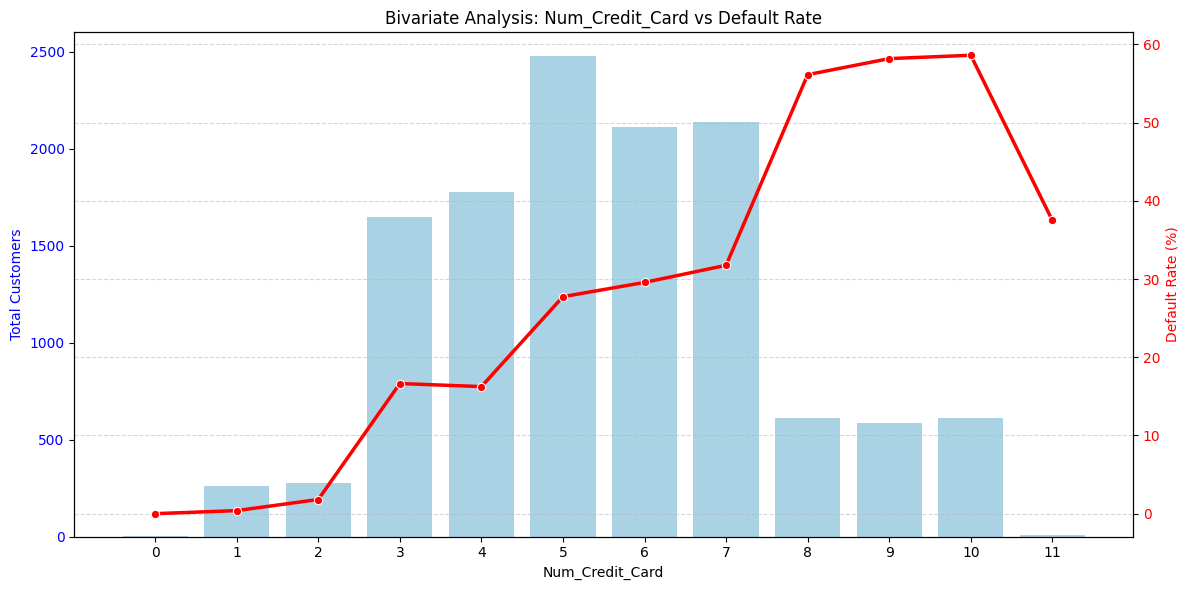

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert Spark DataFrame to Pandas DataFrame for visualization
# Note: Only do this after aggregation when the dataset size is small
pdf_num_credit_bivariate = df_num_credit_bivariate.toPandas()

# 2. Set up the matplotlib figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Plot Total_Customers as a Bar Chart on the primary y-axis
sns.barplot(
    data=pdf_num_credit_bivariate, 
    x='Num_Credit_Card', 
    y='Total_Customers', 
    color='skyblue', 
    alpha=0.8, 
    ax=ax1
)
ax1.set_ylabel('Total Customers', color='blue')
ax1.set_xlabel('Num_Credit_Card')
ax1.tick_params(axis='y', labelcolor='blue')

# 4. Create a secondary y-axis to plot the Default Rate
ax2 = ax1.twinx()

# 5. Plot Default_Rate_Percent as a Line Chart on the secondary y-axis
sns.lineplot(
    data=pdf_num_credit_bivariate, 
    x='Num_Credit_Card', 
    y='Default_Rate_Percent', 
    color='red', 
    marker='o', 
    linewidth=2.5, 
    ax=ax2
)
ax2.set_ylabel('Default Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 6. Add title and display the plot
plt.title('Bivariate Analysis: Num_Credit_Card vs Default Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Similar to num_credit_card and num_of_loans

### Delay from due date

In [104]:
from pyspark.sql.functions import col, when, count, sum, avg, round

# 1. Select relevant columns and filter out nulls
df_delay = df_joined_full.select("Customer_ID", "Delay_from_due_date", "isDefault") \
    .filter(col("Delay_from_due_date").isNotNull())

# 2. Create custom buckets based on typical credit risk definitions (DPD - Days Past Due)
df_delay_bucketed = df_delay.withColumn(
    "Delay_Bucket",
    when(col("Delay_from_due_date") <= 0, "0. On Time or Early")
    .when((col("Delay_from_due_date") > 0) & (col("Delay_from_due_date") <= 15), "1. 1-15 Days Late")
    .when((col("Delay_from_due_date") > 15) & (col("Delay_from_due_date") <= 30), "2. 16-30 Days Late")
    .when((col("Delay_from_due_date") > 30) & (col("Delay_from_due_date") <= 60), "3. 31-60 Days Late")
    .otherwise("4. > 60 Days Late")
)

# 3. Aggregate to calculate Default Rate per Delay Bucket
df_delay_bivariate = df_delay_bucketed.groupBy("Delay_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Delay_from_due_date"), 2).alias("Avg_Delay_Days")
    ) \
    .orderBy("Delay_Bucket")

# Show the aggregated result
df_delay_bivariate.show()

+-------------------+---------------+--------------+--------------------+--------------+
|       Delay_Bucket|Total_Customers|Total_Defaults|Default_Rate_Percent|Avg_Delay_Days|
+-------------------+---------------+--------------+--------------------+--------------+
|0. On Time or Early|            146|            14|                9.59|           0.0|
|  1. 1-15 Days Late|           5331|           816|               15.31|          8.95|
| 2. 16-30 Days Late|           4638|          1445|               31.16|         22.88|
| 3. 31-60 Days Late|           2227|          1225|               55.01|         44.91|
|  4. > 60 Days Late|            158|           102|               64.56|         62.08|
+-------------------+---------------+--------------+--------------------+--------------+



### Payment_behavior

In [150]:
from pyspark.sql.functions import col, when, count, sum, avg, round

# 1. Select relevant columns
df_payment_beh = df_joined_full.select("Customer_ID", "Payment_Behaviour", "isDefault")

# 2. Clean dirty data: Replace '!@9#%8' or nulls with 'UNKNOWN'
df_payment_clean = df_payment_beh.withColumn(
    "Payment_Behaviour_Clean",
    when(
        (col("Payment_Behaviour") == "!@9#%8") | (col("Payment_Behaviour").isNull()), 
        "UNKNOWN"
    ).otherwise(col("Payment_Behaviour"))
)

# 3. Aggregate to calculate Default Rate per Payment Behaviour
df_payment_bivariate = df_payment_clean.groupBy("Payment_Behaviour_Clean") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy(col("Default_Rate_Percent").desc())

# Show the cleaned and aggregated results
print("--- Bivariate Analysis: Payment Behaviour ---")
df_payment_bivariate.show(truncate=False)

--- Bivariate Analysis: Payment Behaviour ---


[Stage 1411:>                                                       (0 + 1) / 1]

+--------------------------------+---------------+--------------+--------------------+
|Payment_Behaviour_Clean         |Total_Customers|Total_Defaults|Default_Rate_Percent|
+--------------------------------+---------------+--------------+--------------------+
|Low_spent_Small_value_payments  |3202           |1183          |36.95               |
|Low_spent_Medium_value_payments |1686           |533           |31.61               |
|UNKNOWN                         |998            |289           |28.96               |
|Low_spent_Large_value_payments  |1300           |350           |26.92               |
|High_spent_Small_value_payments |1389           |359           |25.85               |
|High_spent_Medium_value_payments|2242           |532           |23.73               |
|High_spent_Large_value_payments |1683           |356           |21.15               |
+--------------------------------+---------------+--------------+--------------------+



/tmp/ipykernel_4912/977477352.py:9: FutureWarning:                              

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


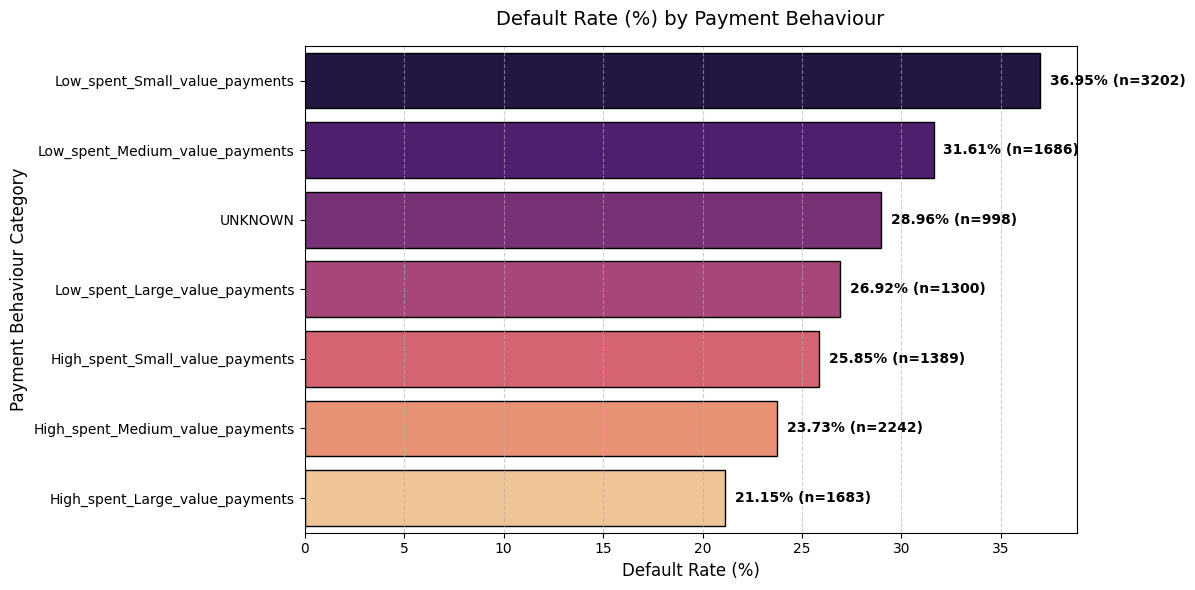

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the aggregated Spark DataFrame to Pandas
pdf_payment_bivariate = df_payment_bivariate.toPandas()

# 2. Set up the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=pdf_payment_bivariate, 
    x='Default_Rate_Percent', 
    y='Payment_Behaviour_Clean', 
    palette='magma', # Uses a color gradient reflecting intensity
    edgecolor='black'
)

# 3. Add data labels to the bars
for index, row in pdf_payment_bivariate.iterrows():
    ax.text(
        row['Default_Rate_Percent'] + 0.5, 
        index, 
        f"{row['Default_Rate_Percent']}% (n={row['Total_Customers']})", 
        color='black', 
        va='center',
        fontweight='bold'
    )

plt.title('Default Rate (%) by Payment Behaviour', fontsize=14, pad=15)
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Payment Behaviour Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [153]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

# 1. Transform the master dataframe by splitting Payment_Behaviour into numerical indices
df_transformed = df_joined_full.withColumn(
    "Spend_Level_Idx",
    F.when(F.col("Payment_Behaviour").contains("Low_spent"), "Low")
     .when(F.col("Payment_Behaviour").contains("High_spent"), "High")
     .otherwise("UNKNOWN")
).withColumn(
    "Payment_Value_Level_Idx",
    F.when(F.col("Payment_Behaviour").contains("Small_value"), "Small")
     .when(F.col("Payment_Behaviour").contains("Medium_value"), "Medium")
     .when(F.col("Payment_Behaviour").contains("Large_value"), "Large")
     .otherwise("UNKNOWN")
)

# 2. Bivariate Analysis for Spend_Level_Idx
# Mapping: 0 = Unknown/Dirty, 1 = Low Spent, 2 = High Spent
print("--- Bivariate Analysis: Spend_Level_Idx ---")
df_spend_bivariate = df_transformed.groupBy("Spend_Level_Idx") \
    .agg(
        F.count("*").alias("Total_Customers"),
        F.sum("isDefault").alias("Total_Defaults"),
        F.round(F.avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ).orderBy("Spend_Level_Idx")

df_spend_bivariate.show()

# 3. Bivariate Analysis for Payment_Value_Level_Idx
# Mapping: 0 = Unknown/Dirty, 1 = Small Value, 2 = Medium Value, 3 = Large Value
print("--- Bivariate Analysis: Payment_Value_Level_Idx ---")
df_value_bivariate = df_transformed.groupBy("Payment_Value_Level_Idx") \
    .agg(
        F.count("*").alias("Total_Customers"),
        F.sum("isDefault").alias("Total_Defaults"),
        F.round(F.avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ).orderBy("Payment_Value_Level_Idx")

df_value_bivariate.show()

--- Bivariate Analysis: Spend_Level_Idx ---
+---------------+---------------+--------------+--------------------+
|Spend_Level_Idx|Total_Customers|Total_Defaults|Default_Rate_Percent|
+---------------+---------------+--------------+--------------------+
|           High|           5314|          1247|               23.47|
|            Low|           6188|          2066|               33.39|
|        UNKNOWN|            998|           289|               28.96|
+---------------+---------------+--------------+--------------------+

--- Bivariate Analysis: Payment_Value_Level_Idx ---


[Stage 1439:>                                                       (0 + 1) / 1]

+-----------------------+---------------+--------------+--------------------+
|Payment_Value_Level_Idx|Total_Customers|Total_Defaults|Default_Rate_Percent|
+-----------------------+---------------+--------------+--------------------+
|                  Large|           2983|           706|               23.67|
|                 Medium|           3928|          1065|               27.11|
|                  Small|           4591|          1542|               33.59|
|                UNKNOWN|            998|           289|               28.96|
+-----------------------+---------------+--------------+--------------------+



In [154]:
# Refresh the master dataframe with the new label logic
df_joined_attr = df_attr.join(
    df_default_labels.select("Customer_ID", "isDefault"), 
    on="Customer_ID", 
    how="inner"
)

In [156]:
# =========================================================
# 1. BIVARIATE ANALYSIS FOR OCCUPATION
# =========================================================
print("--- Bivariate Analysis: Default Rate by Occupation ---")

# Handle potential nulls or blanks by filling with 'UNKNOWN'
df_occ_clean = df_joined_attr.withColumn(
    "Occupation_Clean",
    F.when((col("Occupation") == "") | (col("Occupation").isNull()), "UNKNOWN")
     .otherwise(col("Occupation"))
)

df_occ_bivariate = df_occ_clean.groupBy("Occupation_Clean") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy(col("Default_Rate_Percent").desc())

df_occ_bivariate.show(30, truncate=False)


# =========================================================
# 2. BIVARIATE ANALYSIS FOR AGE (BUCKETED)
# =========================================================
print("\n--- Bivariate Analysis: Default Rate by Age Buckets ---")

# Clean Age column (cast to int and filter out impossible values like negative or too high)
df_age_clean = df_joined_attr.withColumn("Age_Int", col("Age").cast("int")) \
    .filter((col("Age").isNotNull()) & (col("Age") > 0) & (col("Age") < 100))

# Discretize Age into 5 equal-frequency buckets
age_discretizer = QuantileDiscretizer(
    numBuckets=5, 
    inputCol="Age_Int", 
    outputCol="Age_Bucket",
    handleInvalid="keep"
)

# 1. Clean Age column: cast to Integer and filter out unrealistic values
df_age_exact = df_joined_attr \
    .withColumn("Age_Int", col("Age").cast("int")) \
    .filter((col("Age_Int").isNotNull()) & (col("Age_Int") > 0) & (col("Age_Int") < 100))

# 2. Bivariate Analysis: Group by exact age to observe granular risk distribution
print("--- Bivariate Analysis: Default Rate by Exact Age ---")
df_age_exact_bivariate = df_age_exact.groupBy("Age_Int") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy("Age_Int")

# Display the granular transformation breakdown
df_age_exact_bivariate.show(100, truncate=False)

--- Bivariate Analysis: Default Rate by Occupation ---
+----------------+---------------+--------------+--------------------+
|Occupation_Clean|Total_Customers|Total_Defaults|Default_Rate_Percent|
+----------------+---------------+--------------+--------------------+
|Accountant      |791            |242           |30.59               |
|Writer          |728            |222           |30.49               |
|Mechanic        |780            |235           |30.13               |
|Teacher         |782            |232           |29.67               |
|Engineer        |793            |234           |29.51               |
|Manager         |736            |217           |29.48               |
|Entrepreneur    |776            |227           |29.25               |
|Developer       |780            |227           |29.1                |
|Journalist      |761            |221           |29.04               |
|Scientist       |789            |226           |28.64               |
|Doctor          |760 

### Other

In [126]:
# Refresh the master dataframe with the new label logic
df_joined_full = df_fin.join(
    df_default_labels.select("Customer_ID", "isDefault"), 
    on="Customer_ID", 
    how="inner"
)

In [127]:
from pyspark.ml.feature import QuantileDiscretizer
from pyspark.sql.functions import col, count, sum, avg, round

# 1. Select and filter valid data for both continuous columns
df_num_1 = df_joined_full.select("Customer_ID", "Changed_Credit_Limit", "Credit_Utilization_Ratio", "isDefault") \
    .filter(col("Changed_Credit_Limit").isNotNull() & col("Credit_Utilization_Ratio").isNotNull())

# 2. Configure discretizers to split each feature into 5 buckets
discretizer_limit = QuantileDiscretizer(numBuckets=5, inputCol="Changed_Credit_Limit", outputCol="Limit_Bucket")
discretizer_util = QuantileDiscretizer(numBuckets=5, inputCol="Credit_Utilization_Ratio", outputCol="Util_Bucket")

# 3. Apply transformations
df_num_1_bucketed = discretizer_limit.fit(df_num_1).transform(df_num_1)
df_num_1_bucketed = discretizer_util.fit(df_num_1_bucketed).transform(df_num_1_bucketed)

# 4. Aggregate for Changed_Credit_Limit
print("--- Bivariate Analysis: Changed_Credit_Limit ---")
df_num_1_bucketed.groupBy("Limit_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Changed_Credit_Limit"), 2).alias("Avg_Value")
    ).orderBy("Limit_Bucket").show()

# 5. Aggregate for Credit_Utilization_Ratio
print("--- Bivariate Analysis: Credit_Utilization_Ratio ---")
df_num_1_bucketed.groupBy("Util_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Credit_Utilization_Ratio"), 2).alias("Avg_Value")
    ).orderBy("Util_Bucket").show()

--- Bivariate Analysis: Changed_Credit_Limit ---


+------------+---------------+--------------------+---------+
|Limit_Bucket|Total_Customers|Default_Rate_Percent|Avg_Value|
+------------+---------------+--------------------+---------+
|         0.0|           2402|               26.56|     2.54|
|         1.0|           2404|               26.12|      6.5|
|         2.0|           2409|               27.44|     9.54|
|         3.0|           2406|               28.93|    13.45|
|         4.0|           2421|               34.41|    20.97|
+------------+---------------+--------------------+---------+

--- Bivariate Analysis: Credit_Utilization_Ratio ---
+-----------+---------------+--------------------+---------+
|Util_Bucket|Total_Customers|Default_Rate_Percent|Avg_Value|
+-----------+---------------+--------------------+---------+
|        0.0|           2410|               30.87|    25.16|
|        1.0|           2399|               28.93|    28.93|
|        2.0|           2408|               28.95|     32.4|
|        3.0|         

In [107]:
# 1. Select and filter valid data
df_num_2 = df_joined_full.select(
    "Customer_ID", "Num_Credit_Inquiries", "Amount_invested_monthly", "Monthly_Balance", "isDefault"
).filter(
    col("Num_Credit_Inquiries").isNotNull() & (col("Num_Credit_Inquiries") >= 0) &
    col("Amount_invested_monthly").isNotNull() & (col("Amount_invested_monthly") >= 0) &
    col("Monthly_Balance").isNotNull()
)

# 2. Configure discretizers
discretizer_inq = QuantileDiscretizer(numBuckets=4, inputCol="Num_Credit_Inquiries", outputCol="Inq_Bucket")
discretizer_inv = QuantileDiscretizer(numBuckets=5, inputCol="Amount_invested_monthly", outputCol="Inv_Bucket")
discretizer_bal = QuantileDiscretizer(numBuckets=5, inputCol="Monthly_Balance", outputCol="Bal_Bucket")

# 3. Apply transformations
df_num_2_bucketed = discretizer_inq.fit(df_num_2).transform(df_num_2)
df_num_2_bucketed = discretizer_inv.fit(df_num_2_bucketed).transform(df_num_2_bucketed)
df_num_2_bucketed = discretizer_bal.fit(df_num_2_bucketed).transform(df_num_2_bucketed)

# 4. Aggregate for Num_Credit_Inquiries
print("--- Bivariate Analysis: Num_Credit_Inquiries ---")
df_num_2_bucketed.groupBy("Inq_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Num_Credit_Inquiries"), 1).alias("Avg_Inquiries")
    ).orderBy("Inq_Bucket").show()

# 5. Aggregate for Amount_invested_monthly
print("--- Bivariate Analysis: Amount_invested_monthly ---")
df_num_2_bucketed.groupBy("Inv_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Amount_invested_monthly"), 2).alias("Avg_Invested")
    ).orderBy("Inv_Bucket").show()

# 6. Aggregate for Monthly_Balance
print("--- Bivariate Analysis: Monthly_Balance ---")
df_num_2_bucketed.groupBy("Bal_Bucket") \
    .agg(
        count("*").alias("Total_Customers"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
        round(avg("Monthly_Balance"), 2).alias("Avg_Balance")
    ).orderBy("Bal_Bucket").show()

--- Bivariate Analysis: Num_Credit_Inquiries ---
+----------+---------------+--------------------+-------------+
|Inq_Bucket|Total_Customers|Default_Rate_Percent|Avg_Inquiries|
+----------+---------------+--------------------+-------------+
|       0.0|           3065|               14.13|          1.8|
|       1.0|           2368|                15.5|          4.4|
|       2.0|           3179|               27.65|          7.0|
|       3.0|           3887|               49.45|         11.4|
+----------+---------------+--------------------+-------------+

--- Bivariate Analysis: Amount_invested_monthly ---
+----------+---------------+--------------------+------------+
|Inv_Bucket|Total_Customers|Default_Rate_Percent|Avg_Invested|
+----------+---------------+--------------------+------------+
|       0.0|           2490|               30.64|       41.88|
|       1.0|           2499|               32.53|       84.67|
|       2.0|           2498|               30.58|      135.25|
|       

In [108]:
from pyspark.sql.functions import col, explode, trim, regexp_replace, count, sum, avg, round

# 1. Select relevant columns
df_loan_array = df_joined_full.select("Customer_ID", "Type_of_Loan", "isDefault") \
    .filter(col("Type_of_Loan").isNotNull())

# 2. Explode the array to get individual loan types
df_exploded = df_loan_array.withColumn("Single_Loan_Type", explode(col("Type_of_Loan")))

# 3. Clean the text data: 
# - Trim whitespaces
# - Remove the word "and" (case-insensitive) using regex replacement
# - Clean up any resulting double spaces or trailing/leading spaces after removal
df_cleaned_text = df_exploded.withColumn(
    "Single_Loan_Type", 
    regexp_replace(col("Single_Loan_Type"), "(?i)\\band\\b", "")
).withColumn(
    "Single_Loan_Type", 
    trim(regexp_replace(col("Single_Loan_Type"), "\\s+", " "))
).filter(
    (col("Single_Loan_Type") != "") & (col("Single_Loan_Type").isNotNull())
)

# 4. Handle duplicates: Deduplicate loan types AT CUSTOMER LEVEL
# If a customer has multiple loans of the exact same type, keep only one distinct record
df_deduplicated = df_cleaned_text.dropDuplicates(["Customer_ID", "Single_Loan_Type"])

# 5. Aggregate to calculate the correct Default Rate per unique Loan Type
df_loan_type_final = df_deduplicated.groupBy("Single_Loan_Type") \
    .agg(
        count("*").alias("Unique_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy(col("Default_Rate_Percent").desc())

# Show the clean and deduplicated results
df_loan_type_final.show(truncate=False)

+-----------------------+----------------+--------------+--------------------+
|Single_Loan_Type       |Unique_Customers|Total_Defaults|Default_Rate_Percent|
+-----------------------+----------------+--------------+--------------------+
|Student Loan           |3880            |1429          |36.83               |
|Auto Loan              |3820            |1404          |36.75               |
|Credit-Builder Loan    |3966            |1452          |36.61               |
|Home Equity Loan       |3925            |1419          |36.15               |
|Mortgage Loan          |3920            |1411          |35.99               |
|Debt Consolidation Loan|3880            |1396          |35.98               |
|Not Specified          |3960            |1424          |35.96               |
|Personal Loan          |3888            |1397          |35.93               |
|Payday Loan            |3993            |1428          |35.76               |
+-----------------------+----------------+----------

In [109]:
from pyspark.sql.functions import col, explode, trim, regexp_replace, count, sum, avg, round

# 1. Filter the master dataframe to keep ONLY customers with exactly 1 loan
df_single_loan_customers = df_joined_full.filter(col("Num_of_Loan") == 1)

# 2. Select relevant columns from this filtered subset
df_loan_array = df_single_loan_customers.select("Customer_ID", "Type_of_Loan", "isDefault") \
    .filter(col("Type_of_Loan").isNotNull())

# 3. Explode the array (since size is 1, this converts the 1-element array to a string column)
df_exploded = df_loan_array.withColumn("Single_Loan_Type", explode(col("Type_of_Loan")))

# 4. Clean the text data: remove "and" (case-insensitive) and clean up extra spaces
df_cleaned_text = df_exploded.withColumn(
    "Single_Loan_Type", 
    regexp_replace(col("Single_Loan_Type"), "(?i)\\band\\b", "")
).withColumn(
    "Single_Loan_Type", 
    trim(regexp_replace(col("Single_Loan_Type"), "\\s+", " "))
).filter(
    (col("Single_Loan_Type") != "") & (col("Single_Loan_Type").isNotNull())
)

# 5. Aggregate to calculate the exact Default Rate per Loan Type for single-loan holders
df_loan_type_single_final = df_cleaned_text.groupBy("Single_Loan_Type") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy(col("Default_Rate_Percent").desc())

# Show the results for customers holding only 1 loan
print("--- Bivariate Analysis: Type of Loan (Only for Customers with Num_of_Loan = 1) ---")
df_loan_type_single_final.show(truncate=False)

--- Bivariate Analysis: Type of Loan (Only for Customers with Num_of_Loan = 1) ---
+-----------------------+---------------+--------------+--------------------+
|Single_Loan_Type       |Total_Customers|Total_Defaults|Default_Rate_Percent|
+-----------------------+---------------+--------------+--------------------+
|Not Specified          |176            |33            |18.75               |
|Payday Loan            |150            |25            |16.67               |
|Auto Loan              |144            |24            |16.67               |
|Student Loan           |155            |23            |14.84               |
|Mortgage Loan          |147            |20            |13.61               |
|Credit-Builder Loan    |160            |19            |11.88               |
|Personal Loan          |159            |18            |11.32               |
|Debt Consolidation Loan|158            |17            |10.76               |
|Home Equity Loan       |142            |14            |9.8

In [134]:
df_joined_full.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: float (nullable = true)
 |-- Monthly_Inhand_Salary: float (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: double (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: float (nullable = true)
 |-- Payment_Beh

In [144]:
from pyspark.sql.functions import col, regexp_extract, coalesce, lit, round, count, sum, avg, months_between, to_date

# Define the anchor input date for calculation
input_date_str = "01-11-2026"  # This can be parameterized as a function argument


# Fill potential Null values with 0 to protect mathematical operations
df_age_clean = df_age_parsed.withColumn(
    "Extracted_Years", coalesce(col("Extracted_Years"), lit(0))
).withColumn(
    "Extracted_Months", coalesce(col("Extracted_Months"), lit(0))
)

# ==========================================
# STEP 2: DYNAMIC TIME-LAPSE CALCULATION
# ==========================================
# Convert extracted years and months from text into total base months
df_age_clean = df_age_clean.withColumn(
    "Base_History_Months", (col("Extracted_Years") * 12) + col("Extracted_Months")
)

# Calculate dynamic month distance between input_date and df_fin.snapshot_date
df_age_clean = df_age_clean.withColumn(
    "Months_From_Input_To_Snapshot", 
    months_between(to_date(lit(input_date_str), "dd-MM-yyyy"), col("snapshot_date"))
)

# Combine base history months with dynamic time-lapse months
df_age_features = df_age_clean.withColumn(
    "Credit_History_Age_Months",
    round(col("Base_History_Months") + col("Months_From_Input_To_Snapshot"), 2)
).withColumn(
    "Credit_History_Age_Years",
    round((col("Base_History_Months") + col("Months_From_Input_To_Snapshot")) / 12, 0).cast("int")
)

# ==========================================
# STEP 3: COLUMN SELECTION & SANITIZATION
# ==========================================
# Explicitly select columns using prefixes to avoid ambiguous column errors
df_age_final = df_age_features.select(
    col("Customer_ID"), 
    col("isDefault"),
    col("snapshot_date"),
    col("Credit_History_Age"), 
    col("Credit_History_Age_Months"), 
    col("Credit_History_Age_Years")
)

# Verification check for the dynamic transformation output
print("--- Data Transformation Verification (Dynamic Timeline) ---")
df_age_final.show(10, truncate=False)

# ==========================================
# STEP 4: BIVARIATE ANALYSIS
# ==========================================
# Group by the calculated dynamic years to analyze risk trends
print("--- Bivariate Analysis: Default Rate by Dynamic Credit History Age (Years) ---")
df_age_bivariate = df_age_final.filter(col("Credit_History_Age_Years") >= 0) \
    .groupBy("Credit_History_Age_Years") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy("Credit_History_Age_Years")

df_age_bivariate.show(30)

--- Data Transformation Verification (Dynamic Timeline) ---
+-----------+---------+-------------+----------------------+-------------------------+------------------------+
|Customer_ID|isDefault|snapshot_date|Credit_History_Age    |Credit_History_Age_Months|Credit_History_Age_Years|
+-----------+---------+-------------+----------------------+-------------------------+------------------------+
|CUS_0x1000 |1        |2023-05-01   |10 Years and 9 Months |171.0                    |14                      |
|CUS_0x1009 |0        |2025-01-01   |31 Years and 0 Months |394.0                    |33                      |
|CUS_0x100b |0        |2024-03-01   |15 Years and 10 Months|222.0                    |19                      |
|CUS_0x1011 |0        |2023-11-01   |15 Years and 10 Months|226.0                    |19                      |
|CUS_0x1013 |0        |2023-12-01   |17 Years and 10 Months|249.0                    |21                      |
|CUS_0x1015 |0        |2023-08-01   |21 Year

In [145]:
from pyspark.sql.functions import col, regexp_extract, coalesce, lit, round, count, sum, avg

# 1. Extract the number of years and months using Regex
df_age_parsed = df_joined_full.withColumn(
    "Extracted_Years", 
    regexp_extract(col("Credit_History_Age"), "(\\d+)\\s*Year", 1).cast("int")
).withColumn(
    "Extracted_Months", 
    regexp_extract(col("Credit_History_Age"), "(\\d+)\\s*Month", 1).cast("int")
)

# 2. Fill Nulls with 0 to avoid calculation errors
df_age_clean = df_age_parsed.withColumn(
    "Extracted_Years", coalesce(col("Extracted_Years"), lit(0))
).withColumn(
    "Extracted_Months", coalesce(col("Extracted_Months"), lit(0))
)

# 3. Calculate Exact Months and Rounded Years, KEEPING Customer_ID and isDefault
df_age_features = df_age_clean.withColumn(
    "Credit_History_Age_Months", 
    (col("Extracted_Years") * 12) + col("Extracted_Months")
).withColumn(
    "Credit_History_Age_Years",
    round(col("Credit_History_Age_Months") / 12, 0).cast("int") # Round to nearest integer year
)

# 4. Select only the necessary columns for the final cleaned DataFrame
df_age_final = df_age_features.select(
    "Customer_ID", 
    "isDefault",
    "Credit_History_Age", 
    "Credit_History_Age_Months", 
    "Credit_History_Age_Years"
)

# Show the cleaned data transformation to verify
print("--- Data Transformation Verification ---")
df_age_final.show(10, truncate=False)

# 5. Perform Bivariate Analysis: Group by the new 'Credit_History_Age_Years'
print("--- Bivariate Analysis: Default Rate by Rounded Credit History Age (Years) ---")
df_age_bivariate = df_age_final.filter(col("Credit_History_Age_Years") > 0) \
    .groupBy("Credit_History_Age_Years") \
    .agg(
        count("*").alias("Total_Customers"),
        sum("isDefault").alias("Total_Defaults"),
        round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent")
    ) \
    .orderBy("Credit_History_Age_Years")

df_age_bivariate.show(30)

--- Data Transformation Verification ---
+-----------+---------+----------------------+-------------------------+------------------------+
|Customer_ID|isDefault|Credit_History_Age    |Credit_History_Age_Months|Credit_History_Age_Years|
+-----------+---------+----------------------+-------------------------+------------------------+
|CUS_0x1000 |1        |10 Years and 9 Months |129                      |11                      |
|CUS_0x1009 |0        |31 Years and 0 Months |372                      |31                      |
|CUS_0x100b |0        |15 Years and 10 Months|190                      |16                      |
|CUS_0x1011 |0        |15 Years and 10 Months|190                      |16                      |
|CUS_0x1013 |0        |17 Years and 10 Months|214                      |18                      |
|CUS_0x1015 |0        |21 Years and 5 Months |257                      |21                      |
|CUS_0x1018 |1        |14 Years and 3 Months |171                      |14   

- Annual

## Bivariate for clickstream

In [146]:
from pyspark.sql.functions import col, count, avg, round
from pyspark.ml.feature import QuantileDiscretizer

# 1. Join df_click with df_default_labels to get the 'isDefault' target
# Assuming df_click has 'Customer_ID' as the primary key
df_click_joined = df_click.join(
    df_default_labels.select("Customer_ID", "isDefault"),
    on="Customer_ID",
    how="inner"
)

# 2. STRATEGY 1: Compute Correlation for all 20 features to rank their importance
print("--- Correlation with isDefault (Ranking Top Features) ---")
feature_cols = [f"fe_{i}" for i in range(1, 21)]
correlations = []

for feat in feature_cols:
    # Filter out nulls before calculating correlation
    valid_data = df_click_joined.filter(col(feat).isNotNull())
    try:
        # Calculate Pearson correlation coefficient
        r = valid_data.stat.corr(feat, "isDefault")
        if r is not None:
            correlations.append((feat, r))
    except Exception as e:
        print(f"[WARNING] Could not calculate correlation for {feat}: {e}")

# Sort features by absolute correlation value (descending)
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

# Display top 5 most impactful features
for feat, r in correlations[:5]:
    print(f"Feature {feat}: {r:.4f}")

# 3. STRATEGY 2: Dynamic Bivariate Analysis Function
def analyze_dynamic_feature(df, feature_name, num_buckets=5):
    """
    Dynamically buckets a continuous feature and calculates Default Rate.
    """
    print(f"\n--- Bivariate Analysis for: {feature_name} ---")
    
    df_valid = df.filter(col(feature_name).isNotNull())
    
    # Initialize discretizer
    discretizer = QuantileDiscretizer(
        numBuckets=num_buckets, 
        inputCol=feature_name, 
        outputCol=f"{feature_name}_Bucket",
        handleInvalid="keep"
    )
    
    # Fit and transform
    df_bucketed = discretizer.fit(df_valid).transform(df_valid)
    
    # Aggregate Default Rate
    result = df_bucketed.groupBy(f"{feature_name}_Bucket") \
        .agg(
            count("*").alias("Total_Customers"),
            round(avg("isDefault") * 100, 2).alias("Default_Rate_Percent"),
            round(avg(feature_name), 4).alias(f"Avg_{feature_name}_Value")
        ).orderBy(f"{feature_name}_Bucket")
        
    result.show()
    return result

# 4. Apply the function to the TOP 2 features found from the correlation step
top_1_feature = correlations[0][0]
top_2_feature = correlations[1][0]

df_top1_bivariate = analyze_dynamic_feature(df_click_joined, top_1_feature)
df_top2_bivariate = analyze_dynamic_feature(df_click_joined, top_2_feature)

--- Correlation with isDefault (Ranking Top Features) ---
Feature fe_10: -0.1133
Feature fe_5: 0.1093
Feature fe_4: 0.0890
Feature fe_9: -0.0874
Feature fe_3: 0.0707

--- Bivariate Analysis for: fe_10 ---
+------------+---------------+--------------------+---------------+
|fe_10_Bucket|Total_Customers|Default_Rate_Percent|Avg_fe_10_Value|
+------------+---------------+--------------------+---------------+
|         0.0|          42807|               36.27|        -23.718|
|         1.0|          42814|               31.29|        63.7427|
|         2.0|          42888|               29.02|       117.0544|
|         3.0|          43192|               25.95|       170.4547|
|         4.0|          43675|               22.01|       258.0375|
+------------+---------------+--------------------+---------------+


--- Bivariate Analysis for: fe_5 ---
+-----------+---------------+--------------------+--------------+
|fe_5_Bucket|Total_Customers|Default_Rate_Percent|Avg_fe_5_Value|
+-----------

In [147]:
for i in range(20):
    analyze_dynamic_feature(df_click_joined, correlations[i][0])


--- Bivariate Analysis for: fe_10 ---
+------------+---------------+--------------------+---------------+
|fe_10_Bucket|Total_Customers|Default_Rate_Percent|Avg_fe_10_Value|
+------------+---------------+--------------------+---------------+
|         0.0|          42807|               36.27|        -23.718|
|         1.0|          42814|               31.29|        63.7427|
|         2.0|          42888|               29.02|       117.0544|
|         3.0|          43192|               25.95|       170.4547|
|         4.0|          43675|               22.01|       258.0375|
+------------+---------------+--------------------+---------------+


--- Bivariate Analysis for: fe_5 ---
+-----------+---------------+--------------------+--------------+
|fe_5_Bucket|Total_Customers|Default_Rate_Percent|Avg_fe_5_Value|
+-----------+---------------+--------------------+--------------+
|        0.0|          42620|                22.0|      -34.7815|
|        1.0|          43443|               26

## Feature Engineering

- Debt_to_Income_Ratio
- EMI_to_Salary_Ratio
- Savings_Propensity
- is_Credit_Age_gt_15

In [148]:
import pyspark.sql.functions as F

# 1. Start with the joined dataframe (Silver Layer)
df_gold = df_joined_full \
    .withColumn(
        "Debt_to_Income_Ratio",
        F.when(
            (F.col("Annual_Income").isNotNull()) & (F.col("Annual_Income") > 0),
            F.col("Outstanding_Debt") / F.col("Annual_Income")
        ).otherwise(0.0)
    ) \
    .withColumn(
        "EMI_to_Salary_Ratio",
        F.when(
            (F.col("Monthly_Inhand_Salary").isNotNull()) & (F.col("Monthly_Inhand_Salary") > 0),
            F.col("Total_EMI_per_month") / F.col("Monthly_Inhand_Salary")
        ).otherwise(0.0)
    ) \
    .withColumn(
        "Savings_Propensity",
        F.when(
            (F.col("Monthly_Inhand_Salary").isNotNull()) & (F.col("Monthly_Inhand_Salary") > 0),
            (F.coalesce(F.col("Monthly_Balance"), F.lit(0.0)) + F.coalesce(F.col("Amount_invested_monthly"), F.lit(0.0))) / F.col("Monthly_Inhand_Salary")
        ).otherwise(0.0)
    )

# 2. Extract Credit History Age to numeric values to construct the Flag
df_gold = df_gold \
    .withColumn(
        "Extracted_Years", 
        F.coalesce(F.regexp_extract(F.col("Credit_History_Age"), "(\\d+)\\s*Year", 1).cast("int"), F.lit(0))
    ) \
    .withColumn(
        "Extracted_Months", 
        F.coalesce(F.regexp_extract(F.col("Credit_History_Age"), "(\\d+)\\s*Month", 1).cast("int"), F.lit(0))
    ) \
    .withColumn(
        "Credit_History_Age_Years",
        F.round(((F.col("Extracted_Years") * 12) + F.col("Extracted_Months")) / 12, 0).cast("int")
    ) \
    .withColumn(
        "is_Credit_Age_gt_15",
        F.when(F.col("Credit_History_Age_Years") > 15, 1).otherwise(0)
    )

# 3. Clean up intermediate columns used for text extraction
df_gold = df_gold.drop("Extracted_Years", "Extracted_Months")

# 4. Verify the newly created Gold Layer features
print("[SUCCESS] Gold Layer transformations applied successfully.")
df_gold.select(
    "Customer_ID", 
    "Debt_to_Income_Ratio", 
    "EMI_to_Salary_Ratio", 
    "Savings_Propensity", 
    "Credit_History_Age_Years",
    "is_Credit_Age_gt_15",
    "isDefault"
).show(10, truncate=False)

[SUCCESS] Gold Layer transformations applied successfully.


+-----------+---------------------+---------------------+-------------------+------------------------+-------------------+---------+
|Customer_ID|Debt_to_Income_Ratio |EMI_to_Salary_Ratio  |Savings_Propensity |Credit_History_Age_Years|is_Credit_Age_gt_15|isDefault|
+-----------+---------------------+---------------------+-------------------+------------------------+-------------------+---------+
|CUS_0x1000 |0.0510322315686617   |0.01586789543367016  |0.17651387975195496|11                      |0                  |1        |
|CUS_0x1009 |0.0038743951540339693|0.025495652599215674 |0.13332247192755398|31                      |1                  |0        |
|CUS_0x100b |0.009054204255309214 |0.0                  |0.1272257568455269 |16                      |1                  |0        |
|CUS_0x1011 |0.00803041940305751  |0.023697054426833872 |0.1300573767940838 |16                      |1                  |0        |
|CUS_0x1013 |0.012507582593079486 |0.028636799331159465 |0.1027607095

In [56]:
df_gold.count()

437500

In [57]:
df_joined_full.count()

437500

In [80]:
df_attr_silver.select(countDistinct("Customer_ID")).show(10)

+---------------------------+
|count(DISTINCT Customer_ID)|
+---------------------------+
|                      12500|
+---------------------------+

